# Demo of DISC tomography based on a surface geometry for passive seismic dataset

## Description
This notebook implements DISC based on a surface geometry for passive seismic dataset.
It is designed for generating synthetic data, performing ray path matrix reconstruction, and updating velocity models through gradient-based optimization.


## Date
2026-07

In [1]:
#####Step1 import necessary package

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import lsqr
import sys
from pyekfmm import eikonal,ray2d2  #extract traveltime and ray tracing (new) functions from pyekfmm
from pyseistr.solvers import solver,conjgrad
from pyseistr.solvers import cgstep
from pyseistr.operators import adjnull,matrix_lop
from pyseistr.divne import trianglen_lop
from scipy.ndimage import gaussian_filter
import os

In [2]:
#####Step2 create real Marmousi model
address=os.path.dirname(os.getcwd())
sys.path.insert(0, address)

vel1=address+'/data/vel_fault.npy'
v_true=np.load(vel1)

ny, nx = v_true.shape  ###model size  ny means nz
dx = dy =2      ###spacing rinterval

#########geometry setting 
n_sources = 4 ####number of sources

sourcex=[65,55,48,25,95]
sourcez=[76,110,130,175,50]

sources=np.column_stack((sourcex, sourcez))

n_receivers =100   ####number of recevivers
receivers = [((i*(nx-1)*dx/(n_receivers-1)),0) for i in range(n_receivers)] ### receiver locations (x,y)


In [3]:
#####Step3 build ray path matrix based on eikonal wave equation
sources_x=[ii[0] for ii in sources] ########x coordinates of sources
sources_y=[ii[1] for ii in sources] ########y coordinates of sources

receivers_x=[ii[0] for ii in receivers] ########x coordinates of receivers
receivers_y=[ii[1] for ii in receivers] ########y coordinates of receivers

address=os.path.dirname(os.getcwd())
sys.path.insert(0, address)

from disc.raytrace import * ####import necessary functions for traveltime and ray path calculation  

###compute traveltime for each ray based on eikonal equation
traveltimes,ray_paths=compute_travel_times(v_true, sources, receivers, dx, dy, nx, ny, 1)  

###build ray path matrix 
A=build_ray_matrix(ray_paths, dx, dy, nx, ny, 0)


obst=(np.squeeze(traveltimes))  ####observed traveltime from Eikonal equation

nd=len(obst) #####length of traveltime vector


In [4]:
########Step 5 tomography inversion using DISC method
oniter=20  ####number of outer iteration
initer=8  ####number of inner iteration

vinit = 1 / (gaussian_filter(1 / v_true, 30)) #####initialize starting model

v_low=1500
v_hig=3700

v_disc=vinit

for i in range(oniter):
	_,ray_pathsini=compute_travel_times(v_disc, sources, receivers, dx, dy, nx, ny, 1)   ###ray traceing based on the given model
	opsr=build_ray_matrix(ray_pathsini, dx, dy, nx, ny)  ####build ray path matrix using the initial model

	nm=opsr.toarray().shape[1] 
	par_S={'nm':nm,'nd':nm,'nbox':[6,6,1],'ndat':[nx,ny,1],'ndim':3} ### shaping operator setting
	v_disc=tomoloop(v_disc,opsr,initer,nx,ny,nd,obst,par_S) ### gradient estimation and model update

	v_disc = np.clip(v_disc, v_low, v_hig)
	
	print('iter=',i+1,msecal(obst,np.matmul(opsr.toarray(),1./v_disc.flatten(order='C'))))


iter= 1 2.165479727952115e-05
iter= 2 1.8251947993841852e-05
iter= 3 1.441609809624513e-05
iter= 4 1.1906408148546713e-05
iter= 5 1.0049787705384975e-05
iter= 6 8.396419369337595e-06
iter= 7 7.543433329490609e-06
iter= 8 6.431815152759788e-06
iter= 9 5.325798609095019e-06
iter= 10 4.9084170137238854e-06
iter= 11 4.3982958375219425e-06
iter= 12 3.811813293665888e-06
iter= 13 3.2790922981758554e-06
iter= 14 3.2204930080305753e-06
iter= 15 3.1115758932953605e-06
iter= 16 2.9013109804946004e-06
iter= 17 2.559969427599824e-06
iter= 18 2.425515931521979e-06
iter= 19 2.308355395228641e-06
iter= 20 2.4063700837669896e-06


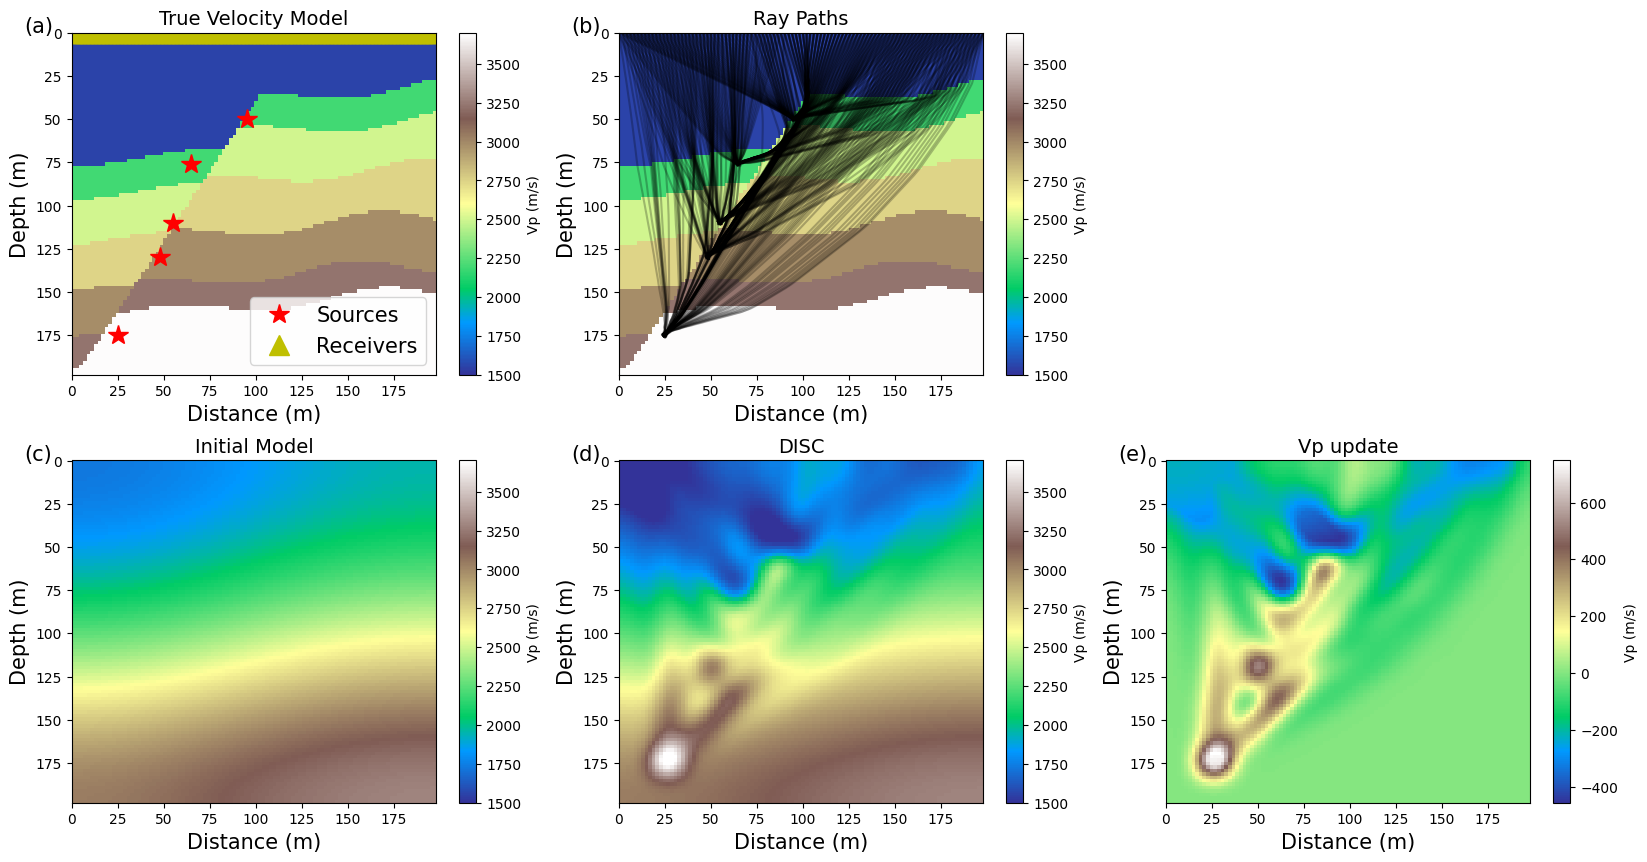

In [ ]:
figadd=address+'/Figure/'
plt.figure(figsize=(20,10))
plt.subplot(2,3,1)
plt.imshow(v_true,cmap='terrain',vmin=v_low,vmax=v_hig,extent=[0,(nx-1)*dx,(ny-1)*dy,0],aspect='auto')
plt.ylabel('Depth (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
plt.xlabel('Distance (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	 
plt.text(-26,0, '(a)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal') 
plt.colorbar(label='Vp (m/s)')
plt.plot(sources_x,sources_y,'r*',  markersize=15)
plt.plot(receivers_x,receivers_y,'y^',  markersize=15)
plt.title('True Velocity Model', fontsize=14)
plt.legend(['Sources','Receivers'],loc='lower right',prop={'family': 'DejaVu Sans', 'size': 15, 'weight': 'normal'})

plt.subplot(2,3,2)
plt.imshow(v_true,cmap='terrain',vmin=v_low,vmax=v_hig,extent=[0,(nx-1)*dx,(ny-1)*dy,0],aspect='auto')
plt.ylabel('Depth (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
plt.xlabel('Distance (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	 
plt.text(-26,0, '(b)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal') 
plt.colorbar(label='Vp (m/s)')
for ray_x, ray_y in ray_paths:
    plt.plot(ray_x, ray_y, 'k-', alpha=0.25)
plt.title('Ray Paths', fontsize=14)

plt.subplot(2,3,4)
plt.imshow(vinit,cmap='terrain',vmin=v_low,vmax=v_hig,extent=[0,(nx-1)*dx,(ny-1)*dy,0],aspect='auto')
plt.ylabel('Depth (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
plt.xlabel('Distance (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	 
plt.text(-26,0, '(c)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal') 
plt.colorbar(label='Vp (m/s)')
plt.title('Initial Model', fontsize=14)

plt.subplot(2,3,5)
plt.imshow(v_disc,cmap='terrain',vmin=v_low,vmax=v_hig,extent=[0,(nx-1)*dx,(ny-1)*dy,0],aspect='auto')
plt.ylabel('Depth (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
plt.xlabel('Distance (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	 
plt.text(-26,0, '(d)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal') 
plt.colorbar(label='Vp (m/s)')
plt.title('DISC', fontsize=14)

plt.subplot(2,3,6)
plt.imshow(v_disc-vinit,cmap='terrain',extent=[0,(nx-1)*dx,(ny-1)*dy,0],aspect='auto')
plt.ylabel('Depth (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
plt.xlabel('Distance (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	 
plt.text(-26,0, '(e)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal') 
plt.colorbar(label='Vp (m/s)')
plt.title('Vp update', fontsize=14)

plt.subplots_adjust(hspace=0.25)
# plt.savefig(figadd+"fault_passive.png", dpi=300,bbox_inches='tight')	
plt.show()